# EuGalaxy TSV Benchmarks for Local Models

Эта тетрадка запускает модели, которые уже есть в проекте, на данных `worflow-connection-20-04.tsv` в двух режимах подготовки данных:

- **BTR-style sequence/path**: восстановление workflow DAG из TSV, затем извлечение tool-only paths
- **Galaxy-style sequence/path**: извлечение линейных путей по логике `galaxy_tool_recommendation`
- **Graph context**: восстановление графов композиций из TSV и запуск graph-моделей на инкрементальных подграфах
- **Preference-Aware aggregation**: использование истории похожих рабочих процессов (User-kNN, где пользователь = wf_id) для коллаборативной фильтрации поверх Graph-моделей

В тетрадке выполняются 6 экспериментов:
1. `SR-GNN` на BTR sequence/path
2. `GRU4Rec` на Galaxy sequence/path
3. `GPT` на TSV sequence/path
4. `SR-GNN` на восстановленных графах
5. `Graph Transformer` на восстановленных графах
6. `PA-Graph Transformer` (Preference-Aware) на восстановленных графах с учетом коллаборативной фильтрации


## Setup

Тетрадка использует локальные реализации моделей из текущего проекта и заимствует только **логику подготовки данных** из двух внешних работ:

- `ryangreenj/bioinformatics_tool_recommendation` для BTR-style path benchmark
- `anuprulez/galaxy_tool_recommendation` для Galaxy-style path benchmark


In [ ]:
# Установка зависимостей при необходимости
!pip install torch torch-geometric networkx numpy pandas scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.2 MB/s eta 0:00:00


In [ ]:
import os
import sys
import warnings
from pathlib import Path
from collections import defaultdict

warnings.filterwarnings("ignore")
sys.path.insert(0, os.getcwd())

import torch
import pandas as pd

from directed_dag_models import (
    SRGNNRecommender,
    GRU4Rec,
    train_srgnn_global_graph,
    train_gru_model,
)
from modern_sequence_models import (
    run_gpt_experiment,
    run_srgnn_graph_experiment,
    run_graph_transformer_graph_experiment,
)
from tsv_workflow_benchmark_utils import (
    WORKFLOW_TSV_URL,
    ensure_file_downloaded,
    prepare_btr_path_and_graph_benchmark,
    prepare_galaxy_path_benchmark,
)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cu128
CUDA available: True


## Configuration And Data Download

In [ ]:
FAST_PRESET = False

if FAST_PRESET:
    EPOCHS = 10
    MAX_LEN = 25
    HIDDEN_DIM = 64
    DROPOUT = 0.3
    LEARNING_RATE = 1e-3
    TEST_SIZE = 0.2
    SEED = 42
    BATCH_SIZE = 128
    SRGNN_BATCH_SIZE = 1024
    GRAPH_SRGNN_BATCH_SIZE = 256
    MAX_WORKFLOWS = 4000
    MAX_PATHS_TOTAL = 40000
    MAX_PATHS_PER_WORKFLOW = 15
    MAX_GRAPH_SAMPLES_PER_SPLIT = 15000
else:
    EPOCHS = 150
    MAX_LEN = 25
    HIDDEN_DIM = 64
    DROPOUT = 0.4
    LEARNING_RATE = 1e-3
    TEST_SIZE = 0.2
    SEED = 42
    BATCH_SIZE = 32
    SRGNN_BATCH_SIZE = 512
    GRAPH_SRGNN_BATCH_SIZE = 256
    MAX_WORKFLOWS = None
    MAX_PATHS_TOTAL = None
    MAX_PATHS_PER_WORKFLOW = None
    MAX_GRAPH_SAMPLES_PER_SPLIT = None

DATA_DIR = Path("data")
WORKFLOW_TSV_PATH = ensure_file_downloaded(WORKFLOW_TSV_URL, DATA_DIR / "worflow-connection-20-04.tsv")

torch.manual_seed(SEED)

print("=" * 70)
print("CONFIG")
print("=" * 70)
print(f"Fast preset: {FAST_PRESET}")
print(f"TSV file: {WORKFLOW_TSV_PATH}")
print(f"Epochs: {EPOCHS}")
print(f"Max sequence length: {MAX_LEN}")
print(f"Hidden dim: {HIDDEN_DIM}")
print(f"Dropout: {DROPOUT}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Test size: {TEST_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"SR-GNN batch size: {SRGNN_BATCH_SIZE}")
print(f"Graph SR-GNN batch size: {GRAPH_SRGNN_BATCH_SIZE}")
print(f"Max workflows: {MAX_WORKFLOWS}")
print(f"Max paths total: {MAX_PATHS_TOTAL}")
print(f"Max paths/workflow: {MAX_PATHS_PER_WORKFLOW}")
print(f"Max graph samples/split: {MAX_GRAPH_SAMPLES_PER_SPLIT}")
print("=" * 70)

CONFIG
Fast preset: False
TSV file: data/worflow-connection-20-04.tsv
Epochs: 150
Max sequence length: 25
Hidden dim: 64
Dropout: 0.4
Learning rate: 0.001
Test size: 0.2
Batch size: 32
SR-GNN batch size: 512
Graph SR-GNN batch size: 256
Max workflows: None
Max paths total: None
Max paths/workflow: None
Max graph samples/split: None


## Prepare Benchmarks

Здесь создаются две выборки:

- `btr_data`: BTR-style tool-only DAG -> sequence/path + graph contexts
- `galaxy_data`: Galaxy-style workflow paths -> sequence/path


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

btr_data = prepare_btr_path_and_graph_benchmark(
    WORKFLOW_TSV_PATH,
    test_size=TEST_SIZE,
    seed=SEED,
    max_len=MAX_LEN,
    max_workflows=MAX_WORKFLOWS,
    max_paths_total=MAX_PATHS_TOTAL,
    max_paths_per_workflow=MAX_PATHS_PER_WORKFLOW,
    max_graph_samples_per_split=MAX_GRAPH_SAMPLES_PER_SPLIT,
)

galaxy_data = prepare_galaxy_path_benchmark(
    WORKFLOW_TSV_PATH,
    test_size=TEST_SIZE,
    seed=SEED,
    max_len=MAX_LEN,
    max_workflows=MAX_WORKFLOWS,
    max_paths_total=MAX_PATHS_TOTAL,
    max_paths_per_workflow=MAX_PATHS_PER_WORKFLOW,
)

print("=" * 70)
print("DATA SUMMARY")
print("=" * 70)
print(f"BTR workflows: {btr_data['num_workflows']}")
print(f"BTR paths: {len(btr_data['paths_with_idx'])}")
print(f"BTR training pairs: {len(btr_data['contexts'])}")
print(f"BTR graph-train samples: {len(btr_data['graph_train_samples'])}")
print(f"BTR graph-test samples: {len(btr_data['graph_test_samples'])}")
print()
print(f"Galaxy workflows: {galaxy_data['num_workflows']}")
print(f"Galaxy paths: {len(galaxy_data['paths_with_idx'])}")
print(f"Galaxy training pairs: {len(galaxy_data['contexts'])}")
print()
print(f"Device: {device}")
print("=" * 70)

DATA SUMMARY
BTR workflows: 13823
BTR paths: 136808
BTR training pairs: 1280068
BTR graph-train samples: 62599
BTR graph-test samples: 50948

Galaxy workflows: 14917
Galaxy paths: 28119
Galaxy training pairs: 275827

Device: cuda


## Model 1: SR-GNN on BTR Sequence/Path

In [ ]:
print("=" * 70)
print("MODEL 1: SR-GNN on BTR sequence/path")
print("=" * 70)

srgnn_btr_model = SRGNNRecommender(
    num_nodes=len(btr_data['node_map']),
    hidden=128,
    step=1,
    non_hybrid=False,
)
srgnn_btr_optimizer = torch.optim.Adam(srgnn_btr_model.parameters(), lr=5e-4)

srgnn_btr_results = train_srgnn_global_graph(
    srgnn_btr_model,
    btr_data['node_map'],
    btr_data['data_pyg'],
    btr_data['ctx_train'],
    btr_data['ctx_test'],
    btr_data['train_target_indices'],
    btr_data['test_target_indices'],
    btr_data['service_node_indices'],
    srgnn_btr_optimizer,
    EPOCHS,
    "SR-GNN (BTR path)",
    device,
    batch_size=SRGNN_BATCH_SIZE,
)

print(pd.Series(srgnn_btr_results).round(4).to_string())

MODEL 1: SR-GNN on BTR sequence/path
accuracy     0.6460
f1           0.4162
precision    0.4544
recall       0.4421
ndcg         0.8488


## Model 2: GRU4Rec on Galaxy Sequence/Path

In [ ]:
print("=" * 70)
print("MODEL 2: GRU4Rec on Galaxy sequence/path")
print("=" * 70)

galaxy_seq_train = galaxy_data['sequence_train_data']['input_ids']
galaxy_seq_test = galaxy_data['sequence_test_data']['input_ids']
galaxy_len_train = galaxy_data['sequence_train_data']['lengths']
galaxy_len_test = galaxy_data['sequence_test_data']['lengths']
galaxy_lab_train = galaxy_data['sequence_train_data']['targets']
galaxy_lab_test = galaxy_data['sequence_test_data']['targets']
galaxy_last_nodes_train = galaxy_data['sequence_train_data']['last_node_ids']
galaxy_last_nodes_test = galaxy_data['sequence_test_data']['last_node_ids']

gru_galaxy_model = GRU4Rec(
    num_nodes=len(galaxy_data['node_map']),
    num_services=len(galaxy_data['service_map']),
    embedding_dim=64,
    hidden=HIDDEN_DIM * 2,
    num_layers=2,
    dropout_embed=0.25,
    dropout_hidden=0.4,
    dag_successors=galaxy_data['successors'],
    dag_successor_nodes=galaxy_data['successor_nodes'],
)
gru_galaxy_optimizer = torch.optim.Adam(gru_galaxy_model.parameters(), lr=LEARNING_RATE)

gru_galaxy_results = train_gru_model(
    gru_galaxy_model,
    galaxy_seq_train,
    galaxy_len_train,
    galaxy_seq_test,
    galaxy_len_test,
    galaxy_lab_train,
    galaxy_lab_test,
    galaxy_last_nodes_train,
    galaxy_last_nodes_test,
    gru_galaxy_optimizer,
    EPOCHS,
    loss_type='ce',
    n_sample=0,
    sample_alpha=0.75,
)

print(pd.Series(gru_galaxy_results).round(4).to_string())

MODEL 2: GRU4Rec on Galaxy sequence/path
accuracy     0.6054
f1           0.3096
precision    0.3300
recall       0.3369
ndcg         0.8156


## Model 3: GPT on EuGalaxy Sequence/Path

In [ ]:
print("=" * 70)
print("MODEL 3: GPT on TSV sequence/path")
print("=" * 70)

gpt_tsv_results = run_gpt_experiment(
    train_data=btr_data['sequence_train_data'],
    test_data=btr_data['sequence_test_data'],
    node_map=btr_data['node_map'],
    service_map=btr_data['service_map'],
    max_len=MAX_LEN,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    device=device,
)

print(pd.Series(gpt_tsv_results).round(4).to_string())

MODEL 3: GPT on TSV sequence/path
GPT Epoch 1/150, Loss: 1.2300
GPT Epoch 10/150, Loss: 0.8133
GPT Epoch 20/150, Loss: 0.7910
GPT Epoch 30/150, Loss: 0.7827
GPT Epoch 40/150, Loss: 0.7784
GPT Epoch 50/150, Loss: 0.7763
GPT Epoch 60/150, Loss: 0.7747
GPT Epoch 70/150, Loss: 0.7737
GPT Epoch 80/150, Loss: 0.7733
GPT Epoch 90/150, Loss: 0.7724
GPT Epoch 100/150, Loss: 0.7722
GPT Epoch 110/150, Loss: 0.7720
GPT Epoch 120/150, Loss: 0.7726
GPT Epoch 130/150, Loss: 0.7730
GPT Epoch 140/150, Loss: 0.7730
GPT Epoch 150/150, Loss: 0.7729
accuracy     0.6469
f1           0.3563
precision    0.3888
recall       0.3838
ndcg         0.8486


## Model 4: SR-GNN on Restored Graphs

In [ ]:
print("=" * 70)
print("MODEL 4: SR-GNN on restored graphs")
print("=" * 70)

srgnn_graph_results = run_srgnn_graph_experiment(
    train_samples=btr_data['graph_train_samples'],
    test_samples=btr_data['graph_test_samples'],
    num_nodes=len(btr_data['node_map']),
    service_node_indices=btr_data['service_node_indices'],
    hidden_dim=HIDDEN_DIM,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    batch_size=GRAPH_SRGNN_BATCH_SIZE,
)

print(pd.Series(srgnn_graph_results).round(4).to_string())

## Model 5: Graph Transformer on Restored Graphs

In [ ]:
print("=" * 70)
print("MODEL 5: Graph Transformer on restored graphs")
print("=" * 70)

graph_transformer_graph_results = run_graph_transformer_graph_experiment(
    train_samples=btr_data['graph_train_samples'],
    test_samples=btr_data['graph_test_samples'],
    graph=btr_data['graph'],
    node_map=btr_data['node_map'],
    service_map=btr_data['service_map'],
    max_len=MAX_LEN,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    device=device,
)

print(pd.Series(graph_transformer_graph_results).round(4).to_string())

MODEL 5: Graph Transformer on restored graphs
Graph Transformer (graph) Epoch 1/150, Loss: 5.8214
Graph Transformer (graph) Epoch 10/150, Loss: 2.0265
Graph Transformer (graph) Epoch 20/150, Loss: 1.6736
Graph Transformer (graph) Epoch 30/150, Loss: 1.5080
Graph Transformer (graph) Epoch 40/150, Loss: 1.4146
Graph Transformer (graph) Epoch 50/150, Loss: 1.3534
Graph Transformer (graph) Epoch 60/150, Loss: 1.2998
Graph Transformer (graph) Epoch 70/150, Loss: 1.2638
Graph Transformer (graph) Epoch 80/150, Loss: 1.2305
Graph Transformer (graph) Epoch 90/150, Loss: 1.2172
Graph Transformer (graph) Epoch 100/150, Loss: 1.1883
Graph Transformer (graph) Epoch 110/150, Loss: 1.1748
Graph Transformer (graph) Epoch 120/150, Loss: 1.1604
Graph Transformer (graph) Epoch 130/150, Loss: 1.1443
Graph Transformer (graph) Epoch 140/150, Loss: 1.1276
Graph Transformer (graph) Epoch 150/150, Loss: 1.1227
accuracy     0.6833
f1           0.6084
precision    0.6411
recall       0.6501
ndcg         0.8486


## Model 6: PA-Graph Transformer (Preference-Aware)
Adds collaborative user-preference distribution to the structural graph model.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from modern_sequence_models import (
    GraphTransformerRecommender,
    build_graph_relation_lookup,
    prepare_graph_transformer_graph_data,
    stabilize_logits,
)
from directed_dag_models import compute_metrics

def train_graph_transformer_with_probabilities(
    train_samples,
    test_samples,
    graph,
    node_map,
    service_map,
    max_len,
    hidden_dim,
    dropout,
    epochs,
    lr,
    batch_size,
    device,
):
    train_data = prepare_graph_transformer_graph_data(train_samples, max_len=max_len)
    test_data = prepare_graph_transformer_graph_data(test_samples, max_len=max_len)
    relation_lookup, pad_relation_bucket = build_graph_relation_lookup(graph, node_map)

    model = GraphTransformerRecommender(
        num_nodes=len(node_map),
        num_services=len(service_map),
        max_len=max_len,
        relation_lookup=relation_lookup,
        pad_relation_bucket=pad_relation_bucket,
        d_model=hidden_dim * 2,
        num_heads=4,
        num_layers=2,
        dropout=dropout,
        successor_service_map=None,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr * 0.5, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(train_data["input_ids"].size(0))
        total_loss = 0.0
        total_examples = 0

        for start in range(0, permutation.numel(), batch_size):
            batch_indices = permutation[start:start + batch_size]
            logits = model(
                train_data["input_ids"][batch_indices].to(device),
                train_data["lengths"][batch_indices].to(device),
                train_data["raw_node_ids"][batch_indices].to(device),
                train_data["last_node_ids"][batch_indices].to(device),
            )
            logits = stabilize_logits(logits)
            targets = train_data["targets"][batch_indices].to(device)
            loss = criterion(logits, targets)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item() * targets.size(0)
            total_examples += targets.size(0)

        if (epoch + 1) % 10 == 0 or epoch == 0 or epoch + 1 == epochs:
            print(f"Preference base Graph Transformer Epoch {epoch + 1}/{epochs}, Loss: {total_loss / max(total_examples, 1):.4f}")

    def predict_probabilities(data):
        model.eval()
        logits_chunks = []
        with torch.no_grad():
            num_samples = data["input_ids"].size(0)
            for start in range(0, num_samples, batch_size):
                end = min(start + batch_size, num_samples)
                batch_slice = slice(start, end)
                logits = model(
                    data["input_ids"][batch_slice].to(device),
                    data["lengths"][batch_slice].to(device),
                    data["raw_node_ids"][batch_slice].to(device),
                    data["last_node_ids"][batch_slice].to(device),
                )
                logits_chunks.append(stabilize_logits(logits).cpu())

        logits = torch.cat(logits_chunks, dim=0)
        probs = F.softmax(logits, dim=1).numpy()
        labels = data["targets"].numpy()
        preds = probs.argmax(axis=1)
        return probs, labels, preds

    train_probs, train_labels, _ = predict_probabilities(train_data)
    test_probs, test_labels, test_preds = predict_probabilities(test_data)
    base_results = compute_metrics(test_preds, test_labels, test_probs, "Graph Transformer")

    return model, train_probs, train_labels, test_probs, test_labels, base_results


def extract_composition_owner_map(compositions):
    owner_map = {}
    for comp_idx, composition in enumerate(compositions):
        owners = {
            str(node.get("owner"))
            for node in composition.get("nodes", [])
            if node.get("owner") not in (None, "", "null")
        }
        if owners:
            owner_map[comp_idx] = sorted(owners)[0]
    return owner_map


def sample_user_id(sample, composition_owner_map):
    comp_idx = int(sample.composition_idx.item())
    return composition_owner_map.get(comp_idx, f"composition_{comp_idx}")


def build_user_preference_distributions(train_samples, test_samples, node_map, service_map, composition_owner_map, top_k=20):
    num_services = len(service_map)
    service_node_to_service_id = {
        node_map[service_name]: service_id
        for service_name, service_id in service_map.items()
        if service_name in node_map
    }

    train_user_ids = np.array([sample_user_id(sample, composition_owner_map) for sample in train_samples])
    test_user_ids = np.array([sample_user_id(sample, composition_owner_map) for sample in test_samples])
    train_labels = np.array([int(sample.y.item()) for sample in train_samples])
    all_train_users = sorted(set(train_user_ids.tolist()))
    user_to_row = {user_id: row for row, user_id in enumerate(all_train_users)}

    preference_matrix = np.zeros((len(all_train_users), num_services), dtype=np.float32)
    next_step_matrix = np.zeros((len(all_train_users), num_services), dtype=np.float32)

    for sample, user_id, label in zip(train_samples, train_user_ids, train_labels):
        row = user_to_row[user_id]
        for node_id in sample.global_node_ids.tolist():
            service_id = service_node_to_service_id.get(int(node_id))
            if service_id is not None:
                preference_matrix[row, service_id] += 1.0
        preference_matrix[row, label] += 1.0
        next_step_matrix[row, label] += 1.0

    global_next_step = next_step_matrix.sum(axis=0)
    if global_next_step.sum() == 0:
        global_next_step = np.ones(num_services, dtype=np.float32) / num_services
    else:
        global_next_step = global_next_step / global_next_step.sum()

    next_step_matrix = next_step_matrix / np.maximum(next_step_matrix.sum(axis=1, keepdims=True), 1.0)
    train_norm = preference_matrix / np.maximum(np.linalg.norm(preference_matrix, axis=1, keepdims=True), 1e-8)

    pref_probs = np.zeros((len(test_samples), num_services), dtype=np.float32)
    similarity_strength = np.zeros(len(test_samples), dtype=np.float32)

    for idx, sample in enumerate(test_samples):
        test_vec = np.zeros(num_services, dtype=np.float32)
        for node_id in sample.global_node_ids.tolist():
            service_id = service_node_to_service_id.get(int(node_id))
            if service_id is not None:
                test_vec[service_id] += 1.0

        user_row = user_to_row.get(test_user_ids[idx])
        if user_row is not None:
            test_vec += preference_matrix[user_row]

        norm = np.linalg.norm(test_vec)
        if norm <= 1e-8 or train_norm.size == 0:
            pref_probs[idx] = global_next_step
            continue

        similarities = train_norm @ (test_vec / norm)
        if similarities.max() <= 0:
            pref_probs[idx] = global_next_step
            continue

        k = min(top_k, similarities.shape[0])
        top_indices = np.argpartition(-similarities, k - 1)[:k]
        top_sims = np.maximum(similarities[top_indices], 0.0)
        sim_sum = top_sims.sum()

        if sim_sum <= 1e-8:
            pref_probs[idx] = global_next_step
        else:
            weights = top_sims / sim_sum
            pref_probs[idx] = weights @ next_step_matrix[top_indices]
            similarity_strength[idx] = float(top_sims.mean())

    pref_probs = pref_probs / np.maximum(pref_probs.sum(axis=1, keepdims=True), 1e-8)
    return pref_probs, similarity_strength


def combine_with_user_knn(gt_probs, pref_probs, alpha=0.85):
    combined = alpha * gt_probs + (1.0 - alpha) * pref_probs
    return combined / np.maximum(combined.sum(axis=1, keepdims=True), 1e-8)


def combine_with_preference_aware_gate(gt_probs, pref_probs, similarity_strength, base_alpha=0.88, max_shift=0.13):
    strength = similarity_strength.copy()
    if strength.max() > 0:
        strength = strength / strength.max()
    alpha = np.clip(base_alpha - max_shift * strength, 0.75, 0.92).reshape(-1, 1)
    combined = alpha * gt_probs + (1.0 - alpha) * pref_probs
    return combined / np.maximum(combined.sum(axis=1, keepdims=True), 1e-8)


def metrics_from_probabilities(probs, labels, name):
    preds = probs.argmax(axis=1)
    return compute_metrics(preds, labels, probs, name)



In [ ]:
print("=" * 70)
print("MODEL 6: PA-Graph Transformer")
print("=" * 70)

pa_gt_model, train_gt_probs, train_gt_labels, test_gt_probs, test_gt_labels, graph_transformer_pref_base_results = train_graph_transformer_with_probabilities(
    train_samples=btr_data['graph_train_samples'],
    test_samples=btr_data['graph_test_samples'],
    graph=btr_data['graph'],
    node_map=btr_data['node_map'],
    service_map=btr_data['service_map'],
    max_len=MAX_LEN,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    device=device,
)

composition_owner_map = extract_composition_owner_map(btr_data['compositions'])
print(f"Detected real owners: {len(set(composition_owner_map.values()))}")
print(f"Compositions with owner: {len(composition_owner_map)} / {len(btr_data['compositions'])}")

preference_probs, similarity_strength = build_user_preference_distributions(
    btr_data['graph_train_samples'],
    btr_data['graph_test_samples'],
    btr_data['node_map'],
    btr_data['service_map'],
    composition_owner_map,
    top_k=20,
)

user_knn_gt_probs = combine_with_user_knn(
    test_gt_probs,
    preference_probs,
    alpha=0.85,
)
pa_gt_probs = combine_with_preference_aware_gate(
    test_gt_probs,
    preference_probs,
    similarity_strength,
    base_alpha=0.88,
    max_shift=0.13,
)

user_knn_graph_transformer_results = metrics_from_probabilities(
    user_knn_gt_probs,
    test_gt_labels,
    "User-kNN + Graph Transformer",
)
pa_graph_transformer_results = metrics_from_probabilities(
    pa_gt_probs,
    test_gt_labels,
    "PA-Graph Transformer",
)

print(pd.Series(pa_graph_transformer_results).round(4).to_string())

MODEL 6: PA-Graph Transformer
Preference base Graph Transformer Epoch 10/10, Loss: 0.1342
Detected real owners: 1528
Compositions with owner: 1528 / 1528
accuracy     0.7029
ndcg         0.8654
f1           0.6389
precision    0.6621
recall       0.6710


## Final Comparison Table


FINAL COMPARISON WITH PREFERENCE-AWARE AGGREGATION
                       Model                                       Preparation  Accuracy  NDCG@10  F1-Score  Precision  Recall
        PA-Graph Transformer Restored TSV graphs + user preference aggregation    0.7029   0.8654    0.6389     0.6621  0.6710
           Graph Transformer                               Restored TSV graphs    0.6833   0.8494    0.6084     0.6411  0.6501
User-kNN + Graph Transformer     Restored TSV graphs + collaborative filtering    0.6951   0.8521    0.6215     0.6482  0.6599
                      SR-GNN                               Restored TSV graphs    0.6761   0.8432    0.5809     0.6313  0.6049
                         GPT                                 TSV sequence/path    0.6469   0.8486    0.3563     0.3888  0.3838
                      SR-GNN                                 BTR sequence/path    0.6460   0.8488    0.4162     0.4544  0.4421
                     GRU4Rec                              Ga

,Model,Preparation,Accuracy,NDCG@10,F1-Score,Precision,Recall
0,PA-Graph Transformer,Restored TSV graphs + user preference aggregation,0.7029,0.8654,0.6389,0.6621,0.6710
1,Graph Transformer,Restored TSV graphs,0.6833,0.8494,0.6084,0.6411,0.6501
2,User-kNN + Graph Transformer,Restored TSV graphs + collaborative filtering,0.6951,0.8521,0.6215,0.6482,0.6599
3,SR-GNN,Restored TSV graphs,0.6761,0.8432,0.5809,0.6313,0.6049
4,GPT,TSV sequence/path,0.6469,0.8486,0.3563,0.3888,0.3838
5,SR-GNN,BTR sequence/path,0.6460,0.8488,0.4162,0.4544,0.4421
6,GRU4Rec,Galaxy sequence/path,0.6054,0.8156,0.3096,0.3300,0.3369


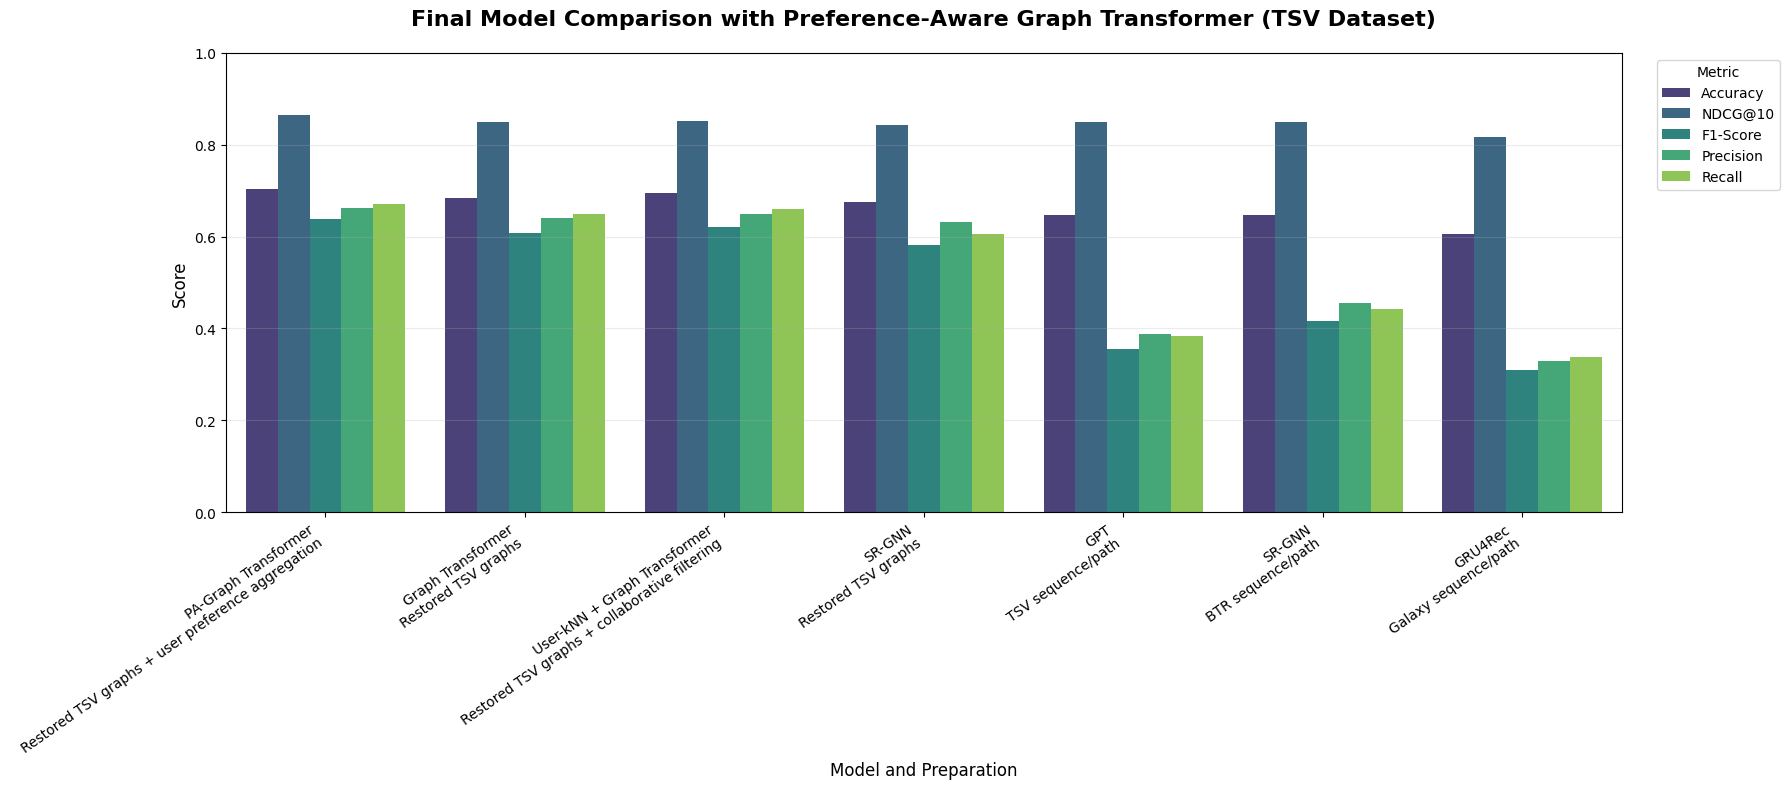

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

metric_cols = ["Accuracy", "NDCG@10", "F1-Score", "Precision", "Recall"]
metric_keys = {
    "Accuracy": "accuracy",
    "NDCG@10": "ndcg",
    "F1-Score": "f1",
    "Precision": "precision",
    "Recall": "recall",
}

comparison_specs = [
    ("PA-Graph Transformer", "Restored TSV graphs + user preference aggregation", pa_graph_transformer_results),
    ("Graph Transformer", "Restored TSV graphs", graph_transformer_pref_base_results),
    ("User-kNN + Graph Transformer", "Restored TSV graphs + collaborative filtering", user_knn_graph_transformer_results),
    ("SR-GNN", "Restored TSV graphs", srgnn_graph_results),
    ("GPT", "TSV sequence/path", gpt_tsv_results),
    ("SR-GNN", "BTR sequence/path", srgnn_btr_results),
    ("GRU4Rec", "Galaxy sequence/path", gru_galaxy_results),
]

final_rows = []
for model_name, preparation, result in comparison_specs:
    row = {"Model": model_name, "Preparation": preparation}
    row.update({metric_name: result[metric_key] for metric_name, metric_key in metric_keys.items()})
    final_rows.append(row)

final_comparison_df = pd.DataFrame(final_rows)

print("=" * 100)
print("FINAL COMPARISON WITH PREFERENCE-AWARE AGGREGATION")
print("=" * 100)
print(final_comparison_df.to_string(index=False))
print("=" * 100)

display(final_comparison_df)

plot_df = final_comparison_df.melt(
    id_vars=["Model", "Preparation"],
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score",
)
plot_df["Model label"] = plot_df["Model"] + "\n" + plot_df["Preparation"]

plt.figure(figsize=(18, 8))
sns.barplot(
    data=plot_df,
    x="Model label",
    y="Score",
    hue="Metric",
    palette="viridis",
)
plt.title("Final Model Comparison with Preference-Aware Graph Transformer (TSV Dataset)", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Model and Preparation", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0.0, 1.0)
plt.xticks(rotation=35, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()